In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')



import numpy as np

# Parameters
sequencing_depth = 500
variant_frequency = 0.01

# Simulate one sequencing experiment
variant_reads = np.random.binomial(
    n=sequencing_depth,
    p=variant_frequency
)

print(f"Sequencing depth: {sequencing_depth}")
print(f"Variant-supporting reads: {variant_reads}")


Sequencing depth: 500
Variant-supporting reads: 7


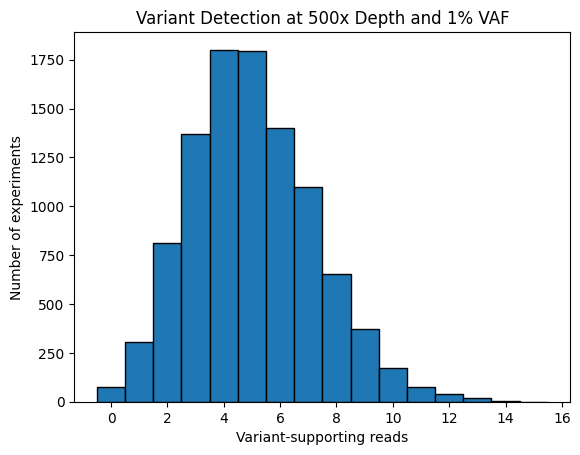

Detection rate: 99.23%


In [8]:

import numpy as np
import matplotlib.pyplot as plt

# Experimental parameters
depth = 500
vaf = 0.01
n_simulations = 10000

# Simulate 10,000 sequencing experiments
variant_reads = np.random.binomial(
    n=depth,
    p=vaf,
    size=n_simulations
)

# Visualize the distribution
plt.hist(
    variant_reads,
    bins=np.arange(variant_reads.max() + 2) - 0.5,
    edgecolor="black"
)

plt.xlabel("Variant-supporting reads")
plt.ylabel("Number of experiments")
plt.title("Variant Detection at 500x Depth and 1% VAF")
plt.show()

# Calculate probability of detecting at least one variant read
detection_rate = np.mean(variant_reads >= 1)

print(f"Detection rate: {detection_rate:.2%}")


In [9]:

# Compare different detection thresholds
for threshold in [1, 2, 3, 5, 10]:
    detection_rate = np.mean(variant_reads >= threshold)

    print(
        f"Threshold: {threshold:2d} reads | "
        f"Detection rate: {detection_rate:.2%}"
    )


Threshold:  1 reads | Detection rate: 99.23%
Threshold:  2 reads | Detection rate: 96.18%
Threshold:  3 reads | Detection rate: 88.05%
Threshold:  5 reads | Detection rate: 56.33%
Threshold: 10 reads | Detection rate: 3.09%


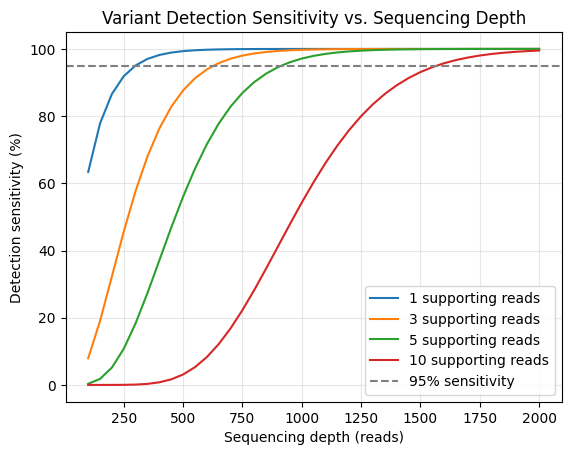

In [10]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Parameters
vaf = 0.01
depths = np.arange(100, 2001, 50)
thresholds = [1, 3, 5, 10]

for threshold in thresholds:
    sensitivity = binom.sf(
        threshold - 1,
        depths,
        vaf
    )

    plt.plot(
        depths,
        sensitivity * 100,
        label=f"{threshold} supporting reads"
    )

plt.axhline(95, color="gray",
            linestyle="--", label="95% sensitivity")

plt.xlabel("Sequencing depth (reads)")
plt.ylabel("Detection sensitivity (%)")
plt.title("Variant Detection Sensitivity vs. Sequencing Depth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [11]:

from scipy.stats import binom

vaf = 0.01
threshold = 3
target_sensitivity = 0.95

for depth in range(1, 2001):
    sensitivity = binom.sf(threshold - 1, depth, vaf)

    if sensitivity >= target_sensitivity:
        print(f"Minimum depth: {depth}x")
        print(f"Sensitivity: {sensitivity:.2%}")
        break


Minimum depth: 628x
Sensitivity: 95.02%


In [12]:

import numpy as np

rng = np.random.default_rng(42)

# Samples contain no real mutation
depth = 500
error_rate = 0.001
n_simulations = 10000

# Simulate erroneous variant-supporting reads
error_reads = rng.binomial(
    n=depth,
    p=error_rate,
    size=n_simulations
)

# Calculate false-positive rates
for threshold in [1, 2, 3, 5, 10]:
    false_positive_rate = np.mean(
        error_reads >= threshold
    )

    print(
        f"Threshold {threshold:2d}: "
        f"False positive rate = {false_positive_rate:.2%}"
    )


Threshold  1: False positive rate = 38.84%
Threshold  2: False positive rate = 8.89%
Threshold  3: False positive rate = 1.50%
Threshold  5: False positive rate = 0.02%
Threshold 10: False positive rate = 0.00%


In [13]:

from scipy.stats import binom

depth = 500
vaf = 0.01
error_rate = 0.001

for threshold in range(1, 11):
    sensitivity = binom.sf(threshold - 1, depth, vaf)
    false_positive_rate = binom.sf(
        threshold - 1, depth, error_rate
    )
    specificity = 1 - false_positive_rate

    balanced_accuracy = (sensitivity + specificity) / 2

    print(
        f"{threshold:2d} reads | "
        f"Sensitivity: {sensitivity:.2%} | "
        f"Specificity: {specificity:.2%} | "
        f"Balanced accuracy: {balanced_accuracy:.2%}"
    )


 1 reads | Sensitivity: 99.34% | Specificity: 60.64% | Balanced accuracy: 79.99%
 2 reads | Sensitivity: 96.02% | Specificity: 90.99% | Balanced accuracy: 93.51%
 3 reads | Sensitivity: 87.66% | Specificity: 98.57% | Balanced accuracy: 93.11%
 4 reads | Sensitivity: 73.64% | Specificity: 99.83% | Balanced accuracy: 86.73%
 5 reads | Sensitivity: 56.04% | Specificity: 99.98% | Balanced accuracy: 78.01%
 6 reads | Sensitivity: 38.40% | Specificity: 100.00% | Balanced accuracy: 69.20%
 7 reads | Sensitivity: 23.71% | Specificity: 100.00% | Balanced accuracy: 61.85%
 8 reads | Sensitivity: 13.23% | Specificity: 100.00% | Balanced accuracy: 56.62%
 9 reads | Sensitivity: 6.71% | Specificity: 100.00% | Balanced accuracy: 53.36%
10 reads | Sensitivity: 3.11% | Specificity: 100.00% | Balanced accuracy: 51.56%


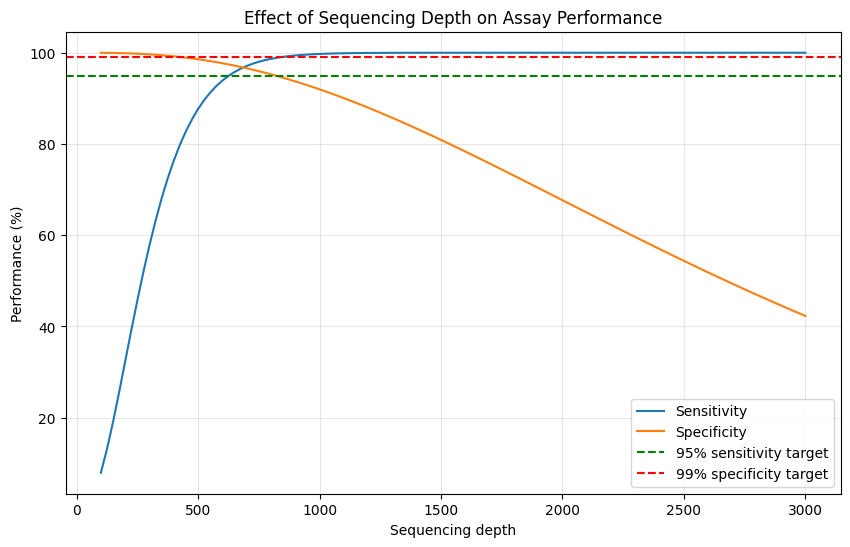

No sequencing depth meets both targets.


In [14]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

vaf = 0.01
error_rate = 0.001
threshold = 3

depths = np.arange(100, 3001, 25)

# Probability of detecting a true variant
sensitivity = binom.sf(
    threshold - 1, depths, vaf
)

# Probability of correctly rejecting a mutation-free sample
specificity = binom.cdf(
    threshold - 1, depths, error_rate
)

plt.figure(figsize=(10, 6))

plt.plot(depths, sensitivity * 100, label="Sensitivity")
plt.plot(depths, specificity * 100, label="Specificity")

plt.axhline(95, linestyle="--", color="green",
            label="95% sensitivity target")
plt.axhline(99, linestyle="--", color="red",
            label="99% specificity target")

plt.xlabel("Sequencing depth")
plt.ylabel("Performance (%)")
plt.title("Effect of Sequencing Depth on Assay Performance")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Check whether any depths meet both targets
valid = depths[
    (sensitivity >= 0.95) &
    (specificity >= 0.99)
]

if len(valid) > 0:
    print(f"First qualifying depth: {valid[0]}x")
else:
    print("No sequencing depth meets both targets.")


In [16]:

import numpy as np
from scipy.stats import binom

vaf = 0.01
threshold = 3

depths = np.arange(100, 3001, 25)
error_rates = [0.001, 0.0005, 0.0001, 0.00001]

for error_rate in error_rates:
    sensitivity = binom.sf(threshold - 1, depths, vaf)
    specificity = binom.cdf(threshold - 1, depths, error_rate)

    valid = depths[
        (sensitivity >= 0.95) &
        (specificity >= 0.99)
    ]

    if len(valid) > 0:
        print(
            f"Error rate {error_rate:.3%}: "
            f"First qualifying depth = {valid[0]}x"
        )
    else:
        print(
            f"Error rate {error_rate:.3%}: "
            "No qualifying depth"
        )


Error rate 0.100%: No qualifying depth
Error rate 0.050%: First qualifying depth = 650x
Error rate 0.010%: First qualifying depth = 650x
Error rate 0.001%: First qualifying depth = 650x
